In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse

# Identify:

Please fill-in your ID in the following cell, **only id numbers, no names!**


<div style="direction:rtl"> 
מלאו בתא הבא את מספר הת.ז שלכם. רק מספר ת.ז., ללא שם!!  
</div>

In [2]:
id = '123456789'
df = pd.DataFrame([id])

In [3]:
df.to_clipboard(index=False,header=False)

---

<div style="direction:rtl"> 
קריאה לקובץ - זה יעבוד עם קובץ הפייתון והקובץ תשובות שלכם יהיו באותה תיקייה
    
    לא לנסות לפתוח את הקובץ עם תוכנה אחרת (דוגמת אקסל), ייתכן שזה יגרום לכך שלא תצליחו לקרוא את הקובץ
</div>

In [4]:
## DO NOT CHANGE THIS LINE
url = 'data_fileB.csv' ## DO NOT CHANGE THIS LINE. PUT YOUR IPYNB FILE AND YOUR DATA FILE IN THE SAME FOLDER. 
df = pd.read_csv(url) ## DO NOT CHANGE THIS LINE. PUT YOUR IPYNB FILE AND YOUR DATA FILE IN THE SAME FOLDER. 
## DO NOT CHANGE THIS LINE
df.head()

,Unnamed: 0,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,date
0,0,1,D,Flight,4,2,177,3,low,F,44,1233,1,2017-02-07
1,1,2,F,Flight,4,5,216,2,low,M,59,3088,1,2017-08-24
2,2,3,A,Flight,2,2,183,4,low,M,48,3374,1,2017-03-14
3,3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,2017-09-13
4,4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,2017-07-23


# Q1 

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [22]:
df["month"] = pd.DatetimeIndex(df['date']).month

In [23]:
df1 = df[df.Mode_of_Shipment == "Ship"]
         

In [24]:
df2 = df1.groupby(["month",'Reached.on.Time_Y.N' ]).agg({'Customer_rating': ['mean', 'std'],\
     'Reached.on.Time_Y.N':['count']     
    })
df2

Customer_rating           Reached.on.Time_Y.N
                                     mean       std               count
month Reached.on.Time_Y.N                                              
1     0                          3.077778  1.447170                 270
      1                          3.042184  1.445772                 403
2     0                          2.952191  1.396318                 251
      1                          2.917431  1.419378                 327
3     0                          2.934615  1.403097                 260
      1                          2.974811  1.377808                 397
4     0                          2.965217  1.429144                 230
      1                          3.079019  1.331325                 367
5     0                          2.859532  1.370960                 299
      1                          3.023560  1.400026                 382
6     0                          3.152941  1.370435                 255
      1                          3.023866  1.432502                 419
7     0                          3.040590  1.438303                 271
      1                          2.991892  1.441709                 370
8     0                          2.866953  1.369110                 233
      1                          2.968085  1.398682                 376
9     0                          3.007843  1.439029                 255
      1                          2.994413  1.378089                 358
10    0                          2.940239  1.391551                 251
      1                          3.071247  1.458617                 393
11    0                          2.829876  1.387481                 241
      1                          3.013477  1.428411                 371
12    0                          2.871658  1.427306                 187
      1                          3.027027  1.413954                 296

The idea was to present **both** shipments that reached on time and those who didn't. Some students understood differently, no points were deducted. Point were deducted when only the shipments that reached on time were presented.\
Another possible solution (we didn't learn it in Spring 2023):

In [33]:
df3 = df1.groupby(["month"]).agg({'Customer_rating': ['mean', 'std']})
df3

Customer_rating          
                 mean       std
month                          
1            3.056464  1.445361
2            2.932526  1.408300
3            2.958904  1.386944
4            3.035176  1.369773
5            2.951542  1.388715
6            3.072700  1.409708
7            3.012480  1.439347
8            2.929392  1.387185
9            3.000000  1.402612
10           3.020186  1.433187
11           2.941176  1.414145
12           2.966874  1.419682

In [38]:
df4 = df1.groupby(["month","Reached.on.Time_Y.N"])[['Customer_rating']].count().unstack().reset_index()
df4

month Customer_rating     
Reached.on.Time_Y.N                     0    1
0                       1             270  403
1                       2             251  327
2                       3             260  397
3                       4             230  367
4                       5             299  382
5                       6             255  419
6                       7             271  370
7                       8             233  376
8                       9             255  358
9                      10             251  393
10                     11             241  371
11                     12             187  296

In [41]:
df3.join(df4, on='month')
#pd.merge(df3, df4, on='month')

Customer_rating           month Customer_rating       
                 mean       std                     0      1
month                                                       
1            3.056464  1.445361   2.0           251.0  327.0
2            2.932526  1.408300   3.0           260.0  397.0
3            2.958904  1.386944   4.0           230.0  367.0
4            3.035176  1.369773   5.0           299.0  382.0
5            2.951542  1.388715   6.0           255.0  419.0
6            3.072700  1.409708   7.0           271.0  370.0
7            3.012480  1.439347   8.0           233.0  376.0
8            2.929392  1.387185   9.0           255.0  358.0
9            3.000000  1.402612  10.0           251.0  393.0
10           3.020186  1.433187  11.0           241.0  371.0
11           2.941176  1.414145  12.0           187.0  296.0
12           2.966874  1.419682   NaN             NaN    NaN

### Q1_b

In [10]:
df.groupby(["Mode_of_Shipment"])[["Customer_rating"]].mean().reset_index().min().to_frame()

,0
Mode_of_Shipment,Flight
Customer_rating,2.982555


# Q2

In [38]:
features = ['ID','Customer_care_calls','Customer_rating','Cost_of_the_Product','Prior_purchases']

In [39]:
melted_df = pd.melt(df[features], id_vars = 'ID', value_vars = features)
melted_df

,ID,variable,value
0,1,Customer_care_calls,4
1,2,Customer_care_calls,4
2,3,Customer_care_calls,2
3,4,Customer_care_calls,3
4,5,Customer_care_calls,2
...,...,...,...
43991,10995,Prior_purchases,5
43992,10996,Prior_purchases,5
43993,10997,Prior_purchases,5
43994,10998,Prior_purchases,6


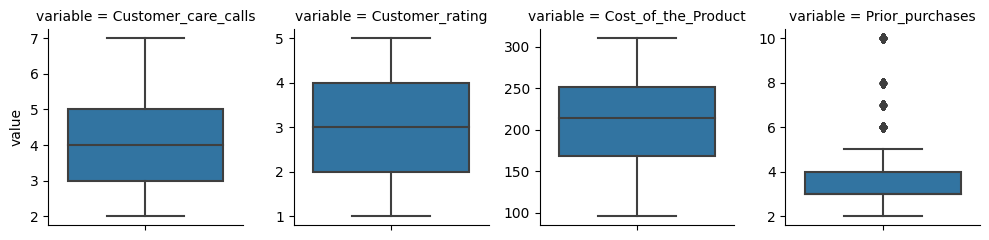

In [50]:
g = sns.FacetGrid(data = melted_df, col="variable",  col_wrap=4, height=2.5, sharey = False)
g.map_dataframe(sns.boxplot, y = 'value')
plt.show()

# Q3

### Q3.a

We won't use the **ID** column because its meaningless. \
There was an **unnamed** column in the data. Point where not deducted for those who chose not to use it, although it was the same as ID\
**Customer_rating** is given after the shipment arrived, so this is another column that it is logical to remove
**Gender** actually might be correlated with the shipment. Maybe only men order cosmetics, and maybe cosmetics tend not to arrive.\
**Date** might also be correlated. It is possible that on certain days (maybe during the weekends?) or certain months (maybe when a lot of employees are on vacation?) there are more shipments that don't arrive.\
**Reached.on.Time_Y.N** is used for the prediction.


In [11]:
features = ['Customer_care_calls', 'Customer_rating','Cost_of_the_Product', 'Prior_purchases', 'Product_importance',\
            'Gender', 'Discount_offered', 'Warehouse_block','Mode_of_Shipment', 'Weight_in_gms', 'date', 'month']

### Q3.b

In [146]:
df4 = pd.get_dummies(df[features])
df4

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,date,month,Product_importance_high,Product_importance_low,...,Gender_F,Gender_M,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
0,4,2,177,3,44,1233,2017-02-07,2,0,1,...,1,0,0,0,0,1,0,1,0,0
1,4,5,216,2,59,3088,2017-08-24,8,0,1,...,0,1,0,0,0,0,1,1,0,0
2,2,2,183,4,48,3374,2017-03-14,3,0,1,...,0,1,1,0,0,0,0,1,0,0
3,3,3,176,4,10,1177,2017-09-13,9,0,0,...,0,1,0,1,0,0,0,1,0,0
4,2,2,184,3,46,2484,2017-07-23,7,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,4,1,252,5,1,1538,2017-02-25,2,0,0,...,1,0,1,0,0,0,0,0,0,1
10995,4,1,232,5,6,1247,2017-07-23,7,0,0,...,1,0,0,1,0,0,0,0,0,1
10996,5,4,242,5,4,1155,2017-11-22,11,0,1,...,1,0,0,0,1,0,0,0,0,1
10997,5,2,223,6,2,1210,2017-02-25,2,0,0,...,0,1,0,0,0,0,1,0,0,1


In [165]:
X= df4[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',\
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'month',\
       'Product_importance_high', 'Product_importance_low',\
       'Product_importance_medium', 'Gender_F', 'Gender_M',\
       'Warehouse_block_A', 'Warehouse_block_B', 'Warehouse_block_C',\
       'Warehouse_block_D', 'Warehouse_block_F', 'Mode_of_Shipment_Flight',\
       'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship']]

In [166]:
y = df['Reached.on.Time_Y.N']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.3, random_state=1)

In [167]:
#define
dt_model1 = DecisionTreeClassifier(random_state=0)
#fit:
dt_model1.fit(X_train, y_train)
#predict:
pred1 = dt_model1.predict(X_test)
#evaluate:
acc = sk.metrics.accuracy_score(pred1, y_test)
acc

0.656060606060606

<AxesSubplot: ylabel='Reached.on.Time_Y.N'>

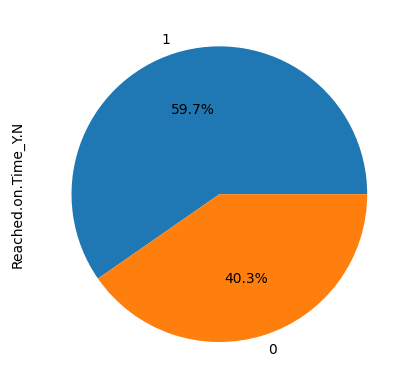

In [52]:
df['Reached.on.Time_Y.N'].value_counts().plot.pie(autopct="%1.1f%%") #try removing this - what happens?

At random, the model's accuracy is 59.7%. We reached an accuracy of 65.6% which is slightly better

### Q3.c

In [169]:
feature_importances = pd.DataFrame(dt_model1.feature_importances_,
                                   index = X.columns,
                                    columns=['importance']).sort_values('importance',
                                                                        ascending=False)
feature_importances.head()

,importance
Discount_offered,0.280331
Weight_in_gms,0.194377
Cost_of_the_Product,0.155200
month,0.069192
Customer_rating,0.051725


# Q4

In [125]:
df2 = df[(df.Weight_in_gms >5500)& (df.Discount_offered<15) ]
len(df2)

1457

<AxesSubplot: xlabel='Discount_offered', ylabel='Count'>

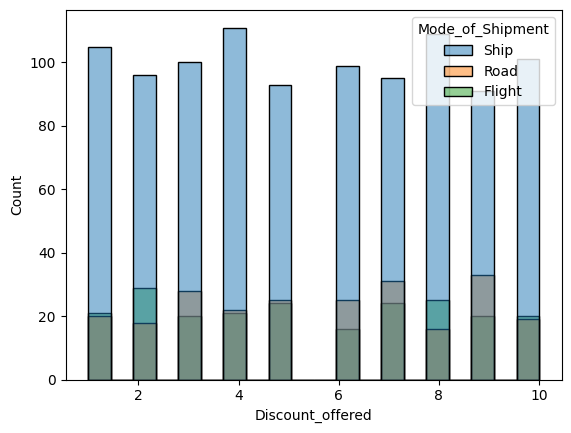

In [127]:
sns.histplot(df2, x= "Discount_offered", hue='Mode_of_Shipment', multiple = 'layer',  bins = 20)